# 03 · Churner Segmentation
**Churn Detective — Telecom Retention Brief**

**Goal:** Cluster the churner population into distinct personas using KMeans. Validate k via elbow + silhouette. Label each cluster with a human-readable persona derived deterministically from centroid signatures. Produce the segment outputs consumed by notebooks 04–05 and the Streamlit dashboard.

**Inputs:** `data/processed/churners_only.parquet`, `data/processed/test.parquet`

**Outputs:**
- `models/kmeans_churner_segments.pkl`  
- `models/kmeans_scaler_v1.pkl`  
- `models/persona_map_v1.pkl`  
- `data/processed/test.parquet` — enriched with `segment_label`  
- `data/processed/train.parquet` — enriched with `segment_label`  
- `outputs/figures/seg_elbow_silhouette.png`  
- `outputs/figures/seg_scatter.png`  
- `outputs/figures/seg_radar.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

from src.segment import (
    select_k, fit_kmeans, centroid_profile,
    assign_personas, predict_segment, segment_summary,
    KMEANS_FEATURES, FEATURE_LABELS,
)

NAVY  = '#111e35'; TEAL  = '#2dd4bf'
AMBER = '#fbbf24'; ROSE  = '#fb7185'
SLATE = '#94a3b8'
SEGMENT_PALETTE = ['#2dd4bf', '#fb7185', '#fbbf24', '#818cf8']

plt.rcParams.update({
    'figure.facecolor': NAVY, 'axes.facecolor': NAVY,
    'axes.edgecolor': '#1a2d4e', 'axes.labelcolor': SLATE,
    'xtick.color': SLATE, 'ytick.color': SLATE,
    'text.color': '#cbd5e1', 'grid.color': '#1a2d4e',
    'grid.linestyle': '--', 'grid.alpha': 0.4,
    'figure.dpi': 130,
})

FIG_DIR   = '../outputs/figures'
MODEL_DIR = '../models'
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data

In [2]:
churners = pd.read_parquet('../data/processed/churners_only.parquet')
test_df  = pd.read_parquet('../data/processed/test.parquet')
train_df = pd.read_parquet('../data/processed/train.parquet')

print(f'Churners (train): {len(churners)} rows')
print(f'Missing KMEANS_FEATURES: {[f for f in KMEANS_FEATURES if f not in churners.columns]}')
churners[KMEANS_FEATURES].describe().round(2)

Churners (train): 2025 rows
Missing KMEANS_FEATURES: []


,monthly_charges,tenure_months,support_calls_3mo,avg_data_gb_3mo,late_payments_6mo,service_frustration_index,charges_per_tenure_month
count,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00
mean,72.66,18.09,2.47,23.81,0.45,2.91,58.96
std,29.06,18.01,2.46,22.10,0.69,2.56,26.67
min,20.08,1.00,0.00,0.00,0.00,0.00,10.25
25%,47.63,4.00,1.00,6.45,0.00,1.00,36.28
50%,73.94,12.00,2.00,19.31,0.00,2.00,56.98
75%,98.09,26.00,3.00,35.67,1.00,4.00,80.63
max,120.00,72.00,14.00,131.15,5.00,15.00,121.27


## 2. K Selection — Elbow + Silhouette

In [3]:
from sklearn.preprocessing import StandardScaler

X_cluster = churners[KMEANS_FEATURES].fillna(0)
scaler_tmp = StandardScaler()
X_scaled   = scaler_tmp.fit_transform(X_cluster)

k_df = select_k(X_scaled, k_range=range(2, 8), random_state=RANDOM_STATE)
print(k_df.to_string(index=False))

 k  inertia  silhouette_score
 2 11314.28            0.2065
 3  8968.77            0.2332
 4  8067.53            0.2223
 5  7296.68            0.2232
 6  6660.13            0.2296
 7  6182.09            0.2086


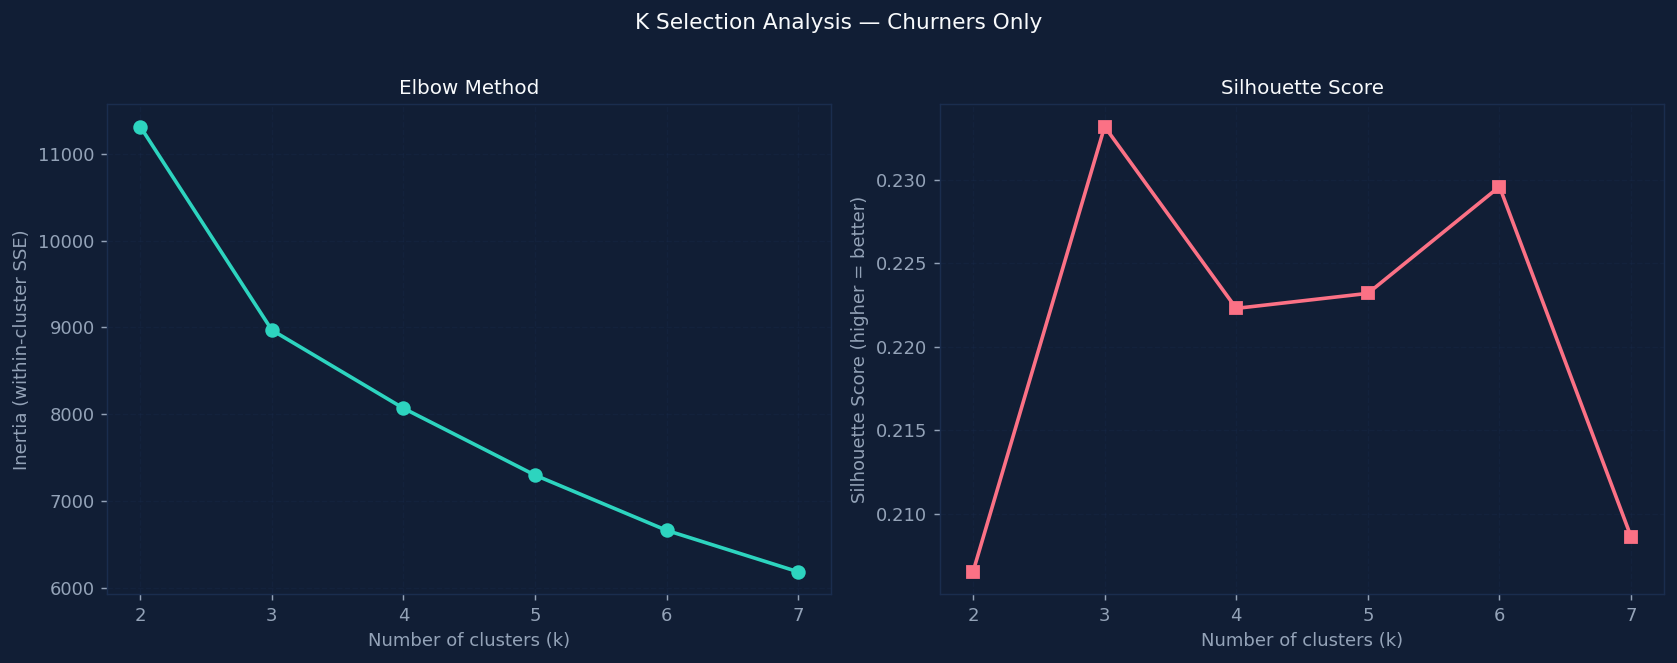


Best k by silhouette: 3
Review the elbow plot above and override K below if needed.


In [4]:
# ── Elbow + silhouette dual plot ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(NAVY)

ax1.plot(k_df['k'], k_df['inertia'], 'o-', color=TEAL, lw=2, ms=7)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (within-cluster SSE)')
ax1.set_title('Elbow Method', color='#f8fafc', fontsize=11)
ax1.set_facecolor(NAVY)
ax1.grid(alpha=0.3)

ax2.plot(k_df['k'], k_df['silhouette_score'], 's-', color=ROSE, lw=2, ms=7)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score (higher = better)')
ax2.set_title('Silhouette Score', color='#f8fafc', fontsize=11)
ax2.set_facecolor(NAVY)
ax2.grid(alpha=0.3)

plt.suptitle('K Selection Analysis — Churners Only',
             color='#f8fafc', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/seg_elbow_silhouette.png',
            bbox_inches='tight', dpi=130, facecolor=NAVY)
plt.show()

best_k = int(k_df.loc[k_df['silhouette_score'].idxmax(), 'k'])
print(f'\nBest k by silhouette: {best_k}')
print('Review the elbow plot above and override K below if needed.')

In [5]:
# ── Set K here — override if elbow/domain knowledge differs ──────────
K = best_k   # typical result for this dataset: 3 or 4
print(f'Using K = {K}')

Using K = 3


## 3. Fit Final KMeans & Assign Personas

In [6]:
km, scaler, labels = fit_kmeans(churners, k=K, random_state=RANDOM_STATE)
churners = churners.copy()
churners['cluster_id'] = labels

profile_df = centroid_profile(churners, labels)
print('=== Centroid Profile (original scale) ===')
print(profile_df.to_string(index=False))

=== Centroid Profile (original scale) ===
 cluster_id   n  revenue_at_risk  pct_of_churners  monthly_charges  tenure_months  support_calls_3mo  avg_data_gb_3mo  late_payments_6mo  service_frustration_index  charges_per_tenure_month
          0 293         20935.86             14.5            71.45          18.18               7.36            24.22               0.57                       7.92                     57.65
          1 859         41373.72             42.4            48.16          15.14               1.57            23.93               0.42                       1.99                     36.45
          2 873         84832.32             43.1            97.17          20.97               1.71            23.56               0.43                       2.14                     81.56


In [7]:
persona_df = assign_personas(profile_df)
print('=== Persona Assignments ===')
for _, row in persona_df.iterrows():
    print(f'\nCluster {int(row["cluster_id"])} → {row["persona_name"]}')
    print(f'  Match score : {row["persona_match_score"]}')
    print(f'  N customers : {int(row["n"])} ({row["pct_of_churners"]:.1f}%)')
    print(f'  Revenue     : ${float(row["revenue_at_risk"]):,.0f}/mo at risk')
    print(f'  Play        : {row["retention_play"]}')

=== Persona Assignments ===

Cluster 0 → 😤 Frustrated Early Adopters
  Match score : 0.75
  N customers : 293 (14.5%)
  Revenue     : $20,936/mo at risk
  Play        : Proactive tech support outreach + free security/support tier upgrade.

Cluster 1 → 💸 Price-Sensitive Shoppers
  Match score : 0.75
  N customers : 859 (42.4%)
  Revenue     : $41,374/mo at risk
  Play        : Offer 15–20% discount for switching to a 1-year contract.

Cluster 2 → 🌙 Quietly Disengaging Veterans
  Match score : 0.75
  N customers : 873 (43.1%)
  Revenue     : $84,832/mo at risk
  Play        : Personal outreach from senior account team + exclusive loyalty plan.


In [8]:
# ── Assign persona labels to churners df ─────────────────────────────
id_to_persona = dict(zip(persona_df['cluster_id'], persona_df['persona_name']))
churners['segment_label'] = churners['cluster_id'].map(id_to_persona)

## 4. Segment Visualisations

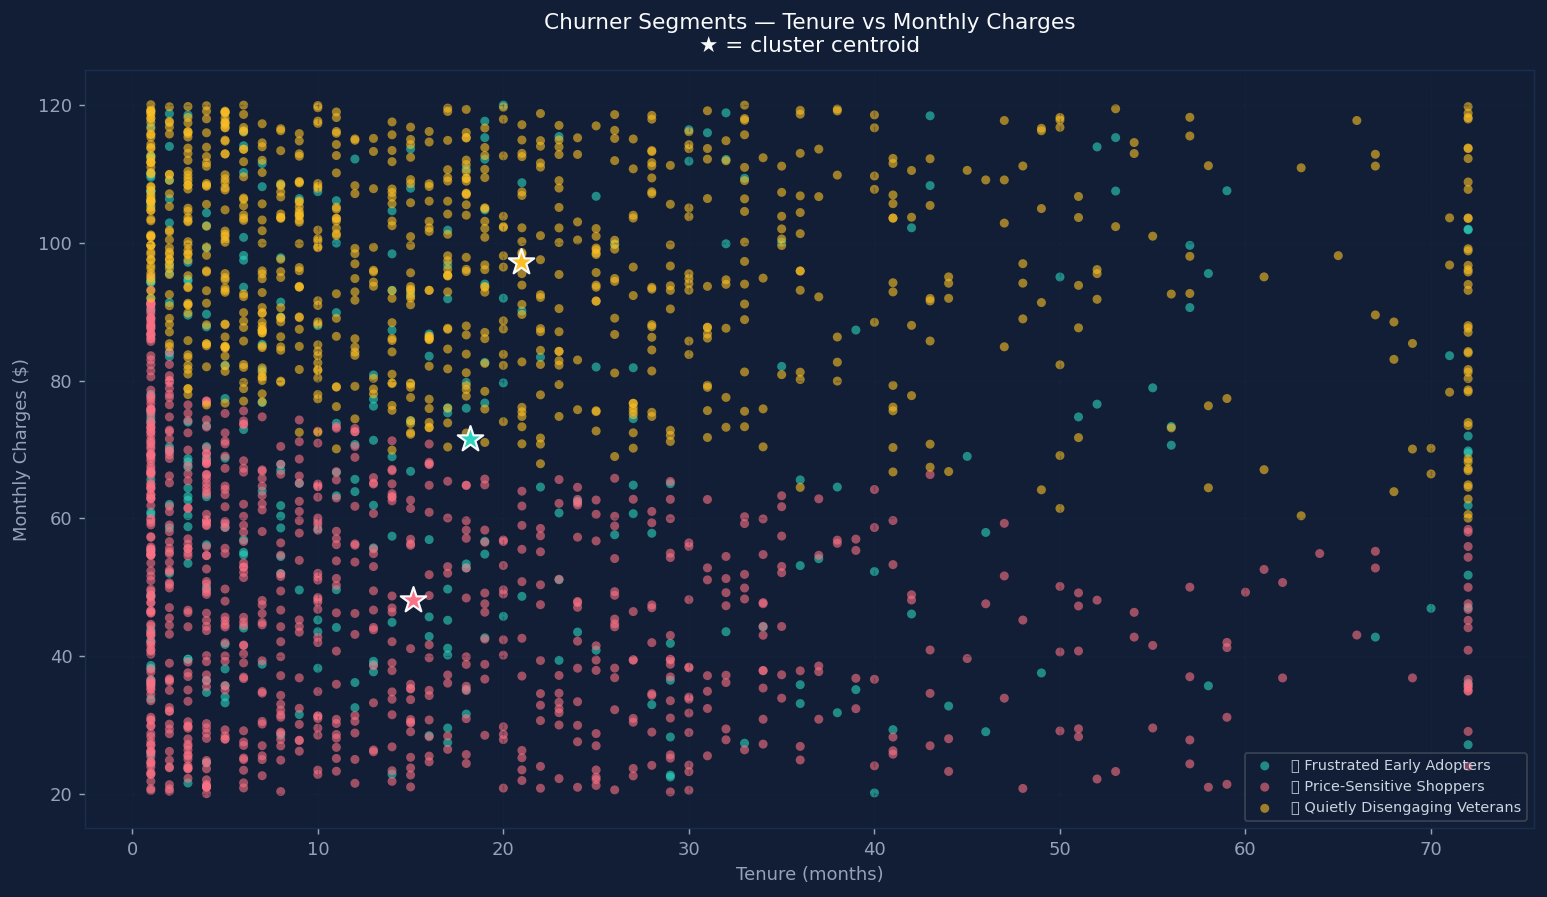

Saved seg_scatter.png


In [9]:
# ── Scatter: tenure vs monthly_charges, coloured by segment ──────────
unique_segs = churners['segment_label'].unique()
color_map   = dict(zip(unique_segs, SEGMENT_PALETTE[:len(unique_segs)]))

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

for seg, color in color_map.items():
    sub = churners[churners['segment_label'] == seg]
    ax.scatter(
        sub['tenure_months'], sub['monthly_charges'],
        c=color, alpha=0.6, s=25, label=seg, edgecolors='none'
    )
    # Centroid marker
    ax.scatter(
        sub['tenure_months'].mean(), sub['monthly_charges'].mean(),
        c=color, s=220, marker='*', edgecolors='#f8fafc', linewidths=1.2,
        zorder=10
    )

ax.set_xlabel('Tenure (months)', fontsize=10)
ax.set_ylabel('Monthly Charges ($)', fontsize=10)
ax.set_title('Churner Segments — Tenure vs Monthly Charges\n★ = cluster centroid',
             color='#f8fafc', fontsize=12, pad=10)
ax.legend(fontsize=8, framealpha=0.2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/seg_scatter.png', bbox_inches='tight',
            dpi=130, facecolor=NAVY)
plt.show()
print('Saved seg_scatter.png')

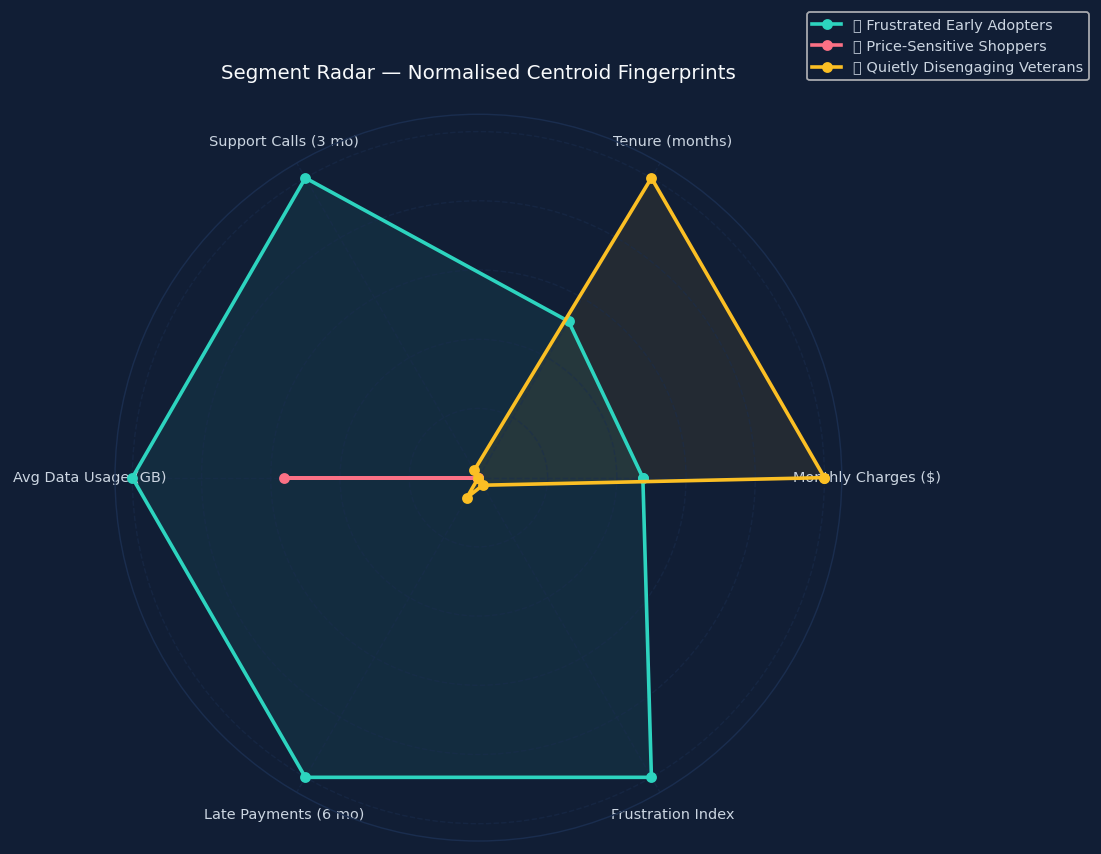

Saved seg_radar.png


In [10]:
# ── Radar chart — normalised centroid fingerprints ────────────────────
from matplotlib.patches import FancyArrowPatch

radar_features = [
    'monthly_charges', 'tenure_months', 'support_calls_3mo',
    'avg_data_gb_3mo', 'late_payments_6mo', 'service_frustration_index'
]

# Normalise centroids to [0, 1] per feature
centroids_norm = profile_df.set_index('cluster_id')[radar_features].copy()
for col in radar_features:
    rng = centroids_norm[col].max() - centroids_norm[col].min()
    centroids_norm[col] = (centroids_norm[col] - centroids_norm[col].min()) / (rng if rng > 0 else 1)

n_feat  = len(radar_features)
angles  = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]  # close polygon

labels_radar = [FEATURE_LABELS.get(f, f) for f in radar_features]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)
ax.spines['polar'].set_color('#1a2d4e')

for i, row in centroids_norm.iterrows():
    persona = id_to_persona.get(i, f'Segment {i}')
    color   = SEGMENT_PALETTE[int(i) % len(SEGMENT_PALETTE)]
    vals    = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', color=color, lw=2, ms=5, label=persona)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=8, color='#cbd5e1')
ax.set_yticklabels([])
ax.set_title('Segment Radar — Normalised Centroid Fingerprints',
             color='#f8fafc', fontsize=11, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
ax.grid(color='#1a2d4e', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/seg_radar.png', bbox_inches='tight',
            dpi=130, facecolor=NAVY)
plt.show()
print('Saved seg_radar.png')

## 5. Predict Segments on Full Dataset & Save

In [11]:
# ── Predict on all rows (train + test, churned & retained) ───────────
for df_name, df in [('train', train_df), ('test', test_df)]:
    df['segment_label'] = predict_segment(df, km, scaler, persona_df)

print('Segment distribution (test set):')
print(test_df['segment_label'].value_counts())

summary = segment_summary(test_df[test_df['churned'] == 1])
print('\nSegment summary (churners in test set):')
print(summary[['segment_label','n_customers','pct_of_total',
               'avg_monthly_charges','total_revenue_at_risk',
               'retention_play']].to_string(index=False))

Segment distribution (test set):
segment_label
💸 Price-Sensitive Shoppers        664
🌙 Quietly Disengaging Veterans    601
😤 Frustrated Early Adopters       135
Name: count, dtype: int64

Segment summary (churners in test set):
                 segment_label  n_customers  pct_of_total  avg_monthly_charges  total_revenue_at_risk                                                        retention_play
🌙 Quietly Disengaging Veterans          210          41.5                96.10               20181.52  Personal outreach from senior account team + exclusive loyalty plan.
    💸 Price-Sensitive Shoppers          226          44.7                46.47               10502.66             Offer 15–20% discount for switching to a 1-year contract.
   😤 Frustrated Early Adopters           70          13.8                76.20                5333.99 Proactive tech support outreach + free security/support tier upgrade.


In [12]:
# ── Save all artifacts ────────────────────────────────────────────────
joblib.dump(km,         f'{MODEL_DIR}/kmeans_churner_segments.pkl')
joblib.dump(scaler,     f'{MODEL_DIR}/kmeans_scaler_v1.pkl')
joblib.dump(persona_df, f'{MODEL_DIR}/persona_map_v1.pkl')

train_df.to_parquet('../data/processed/train.parquet', index=False)
test_df.to_parquet('../data/processed/test.parquet', index=False)

print('Saved:')
print('  models/kmeans_churner_segments.pkl')
print('  models/kmeans_scaler_v1.pkl')
print('  models/persona_map_v1.pkl')
print('  data/processed/train.parquet  (+ segment_label)')
print('  data/processed/test.parquet   (+ segment_label)')
print('\n✓ Notebook 03 complete. Proceed to 04_uplift_modeling.ipynb')

Saved:
  models/kmeans_churner_segments.pkl
  models/kmeans_scaler_v1.pkl
  models/persona_map_v1.pkl
  data/processed/train.parquet  (+ segment_label)
  data/processed/test.parquet   (+ segment_label)

✓ Notebook 03 complete. Proceed to 04_uplift_modeling.ipynb
